**1- Importing the Required Libraries**

We import the libraries needed for data analysis, machine learning, visualization, and statistical plotting: Pandas, NumPy, Scikit-learn, Matplotlib, and Seaborn.

In [ ]:
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
pd.set_option('display.float_format', lambda x: '%.2f' % x)


In [ ]:
from sklearn.model_selection import train_test_split 

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:

sys.path.append(os.path.abspath('..'))

from config.path import DATA_PROCESSED_PATH, HYPERPARAMETER_OPTIMIZATION_RESULTS_PATH, PRE_TRAINED_MODEL_RESULTS_PATH, BEST_MODEL_PATH

In [ ]:
df = pd.read_csv(DATA_PROCESSED_PATH)
df.head()


In [ ]:
X = df.drop(columns=['selling_price'])
Y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [ ]:

rf_param_grid = {
    'model__n_estimators': [100, 200, 300], 
    'model__max_depth': [None,5, 10, 15, 20] , 
    'model__min_samples_split': [2,5,10] , 
    'model__min_samples_leaf' : [1,2,4],
}
xgb_param_grid = {
    'model__n_estimators' : [100, 200, 300] , 
    'model__learning_rate' : [0.01, 0.05, 0.1, 0.2] , 
    'model__max_depth' : [3,6,10] , 
    'model__subsample' : [0.6, 0.8, 1.0] ,
    'model__colsample_bytree' : [0.6 , 0.8, 1.0]
}


In [ ]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler() ) , 
    ('model' , RandomForestRegressor(random_state=42))
])

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler() ) , 
    ('model' , XGBRegressor(random_state=42))
])


rf_grid = GridSearchCV(
    estimator=rf_pipeline, 
    param_grid=rf_param_grid, 
    cv=5, 
    scoring='r2' , 
    n_jobs=-1
)

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline, 
    param_grid=xgb_param_grid, 
    cv=5, 
    scoring='r2' , 
    n_jobs=-1
)




In [ ]:
print("Training Random Forest model...")
rf_grid.fit(X_train, y_train)

print("Training XGBoost model...")
xgb_grid.fit(X_train, y_train)

print('=' * 50)

print("Best parameters for Random Forest:", rf_grid.best_params_)
print("Best parameters for XGBoost:", xgb_grid.best_params_)

print('=' * 50)

print("Best cross-validation scores for Random Forest:", rf_grid.best_score_)
print("Best cross-validation scores for XGBoost:", xgb_grid.best_score_)

In [ ]:
rf_best = rf_grid.best_estimator_
xgb_best = xgb_grid.best_estimator_


rf_pred = rf_best.predict(X_test) 
xgb_pred = xgb_best.predict(X_test)


result = []

result.append({
    'Model': 'Random Forest',
    'MSE': mean_squared_error(y_test, rf_pred) , 
    'MAE': mean_absolute_error(y_test, rf_pred) ,
    'RMSE' : np.sqrt(mean_squared_error(y_test, rf_pred)),
    'R2' : r2_score(y_test, rf_pred)
})

result.append({
    'Model': 'XGBoost',
    'MSE': mean_squared_error(y_test, xgb_pred) ,
    'MAE': mean_absolute_error(y_test, xgb_pred) ,
    'RMSE' : np.sqrt(mean_squared_error(y_test, xgb_pred)) ,
    'R2' : r2_score(y_test, xgb_pred)
})

results_df = pd.DataFrame(result)

results_df.to_csv(HYPERPARAMETER_OPTIMIZATION_RESULTS_PATH, index=False)

In [ ]:
df_baseline = pd.read_csv(PRE_TRAINED_MODEL_RESULTS_PATH)
df_hyperparameter = pd.read_csv(HYPERPARAMETER_OPTIMIZATION_RESULTS_PATH)

In [ ]:
df_concat = pd.concat([df_baseline, df_hyperparameter], axis=0, ignore_index=True )
    

In [ ]:
plt.figure(figsize=(10, 5))

x_labels = [f"Model {df_concat.iloc[i]['Model']} {i+1}" for i in range(len(df_concat))]
y_values = df_concat['R2']

bars = plt.bar(x_labels, y_values, color='skyblue', edgecolor='black', width=0.5)

plt.bar_label(bars, fmt='%.3f', padding=3, fontsize=10, weight='bold')

plt.title('Comparison of R2 Scores', fontsize=14)
plt.xlabel('Models', fontsize=12)
plt.ylabel('R2 Score', fontsize=12)

plt.xticks(rotation=90)


plt.ylim(0, max(y_values) * 1.15)  
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

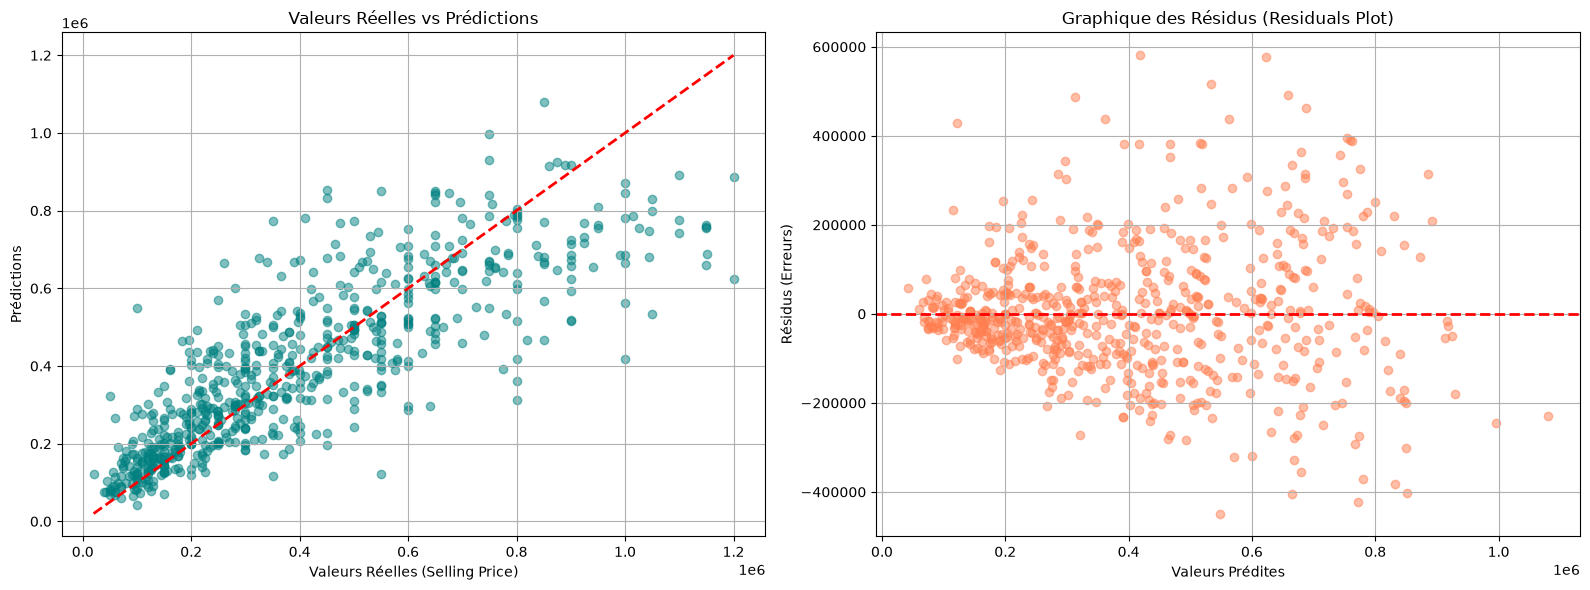

In [25]:

residuals = y_test - xgb_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, xgb_pred, alpha=0.5, color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Valeurs Réelles vs Prédictions')
axes[0].set_xlabel('Valeurs Réelles (Selling Price)')
axes[0].set_ylabel('Prédictions')
axes[0].grid(True)

axes[1].scatter(xgb_pred, residuals, alpha=0.5, color='coral')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_title('Graphique des Résidus (Residuals Plot)')
axes[1].set_xlabel('Valeurs Prédites')
axes[1].set_ylabel('Résidus (Erreurs)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [24]:
joblib.dump(xgb_best, BEST_MODEL_PATH)

['/home/fangyuan/Projects/Prediction-prix-voiture/saved_models/best_model/best_model.pkl']